# Model Training with K-Fold Cross-Validation and Ensemble Stacking

This notebook outlines the process of training multiple base models (LightGBM, CatBoost, XGBoost) using k-fold cross-validation. The out-of-fold (OOF) predictions from these base models are then used to train a meta-model (Logistic Regression) for stacking.

The key steps are:
1. **Setup**: Importing necessary libraries and defining utility functions.
2. **Data Loading and Preprocessing**: Loading the training and test datasets, encoding categorical features, and label encoding the target variable.
3. **Feature Engineering**: Creating new features to potentially improve model performance.
4. **Model Training (K-Fold)**: Training LightGBM, CatBoost, and XGBoost using stratified k-fold cross-validation. 
   - For each base model, after k-fold training, a confusion matrix based on its out-of-fold (OOF) predictions will be generated, plotted, and saved.
5. **Stacking**: Using the OOF predictions from base models as features to train a Logistic Regression meta-model.
6. **Prediction**: Generating final predictions on the test set using the stacked ensemble.
7. **Saving Artifacts**: Saving trained models, encoders, and feature lists for future use.

## 1. Setup

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler # OneHotEncoder removed as custom encoder is used
from sklearn.metrics import confusion_matrix, classification_report # accuracy_score can be added if needed
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from catboost import CatBoostClassifier
import xgboost as xgb
import joblib
import os
import warnings
import kagglehub

# --- Global Configuration Variables ---
USE_GPU = True # Set to True to attempt GPU training, False for CPU
USE_SAMPLE = False # Set to True to use a sample of the training data
SAMPLE_SIZE = 500 # Size of the sample if USE_SAMPLE is True (e.g., 100 to 10000 for meaningful run)
# -------------------------------------

# Suppress warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
SEED = 42

# Configure plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

**Global Variables Note:**
- `USE_GPU`: If set to `True`, the script will attempt to configure LightGBM, XGBoost, and CatBoost for GPU training. Ensure your environment has the necessary GPU drivers and toolkit versions for these libraries.
- `USE_SAMPLE`: If set to `True`, only a subset of the training data (defined by `SAMPLE_SIZE`) will be used. This is useful for faster iterations during development or testing.
- `SAMPLE_SIZE`: Defines the number of rows to sample from the training data if `USE_SAMPLE` is `True`. A reasonable range might be 100 to 10,000 depending on the task.

### 1.2 Utility Functions

#### MAP@k Metric
Calculates Mean Average Precision at k, a common metric for ranking tasks or when multiple correct items can be recommended.

In [2]:
def average_precision_at_k(y_true_single, y_pred_proba_single_top_k_indices):
    """Calculate Average Precision at k for a single sample."""
    # y_pred_proba_single_top_k_indices: array of top k predicted class indices for one sample
    for i, pred_idx in enumerate(y_pred_proba_single_top_k_indices):
        if pred_idx == y_true_single:
            return 1.0 / (i + 1.0)
    return 0.0

def map_at_k(y_true_array, y_pred_proba_array, k=3):
    """Calculate Mean Average Precision at k for a set of samples."""
    # Get top-k predicted class indices for all samples
    top_k_indices_all_samples = np.argsort(y_pred_proba_array, axis=1)[:, ::-1][:, :k]
    
    ap_scores = []
    for i in range(len(y_true_array)):
        ap = average_precision_at_k(y_true_array[i], top_k_indices_all_samples[i])
        ap_scores.append(ap)
    return np.mean(ap_scores)

#### DataFrame Column Encoder
A custom LabelEncoder for specified DataFrame columns.

In [3]:
class DataFrameColumnEncoder:
    """Custom encoder for categorical columns using LabelEncoder."""
    def __init__(self, columns_to_encode):
        self.columns_to_encode = columns_to_encode
        self.encoders_ = {col: LabelEncoder() for col in self.columns_to_encode}
        self.fitted_columns_ = []

    def fit(self, X, y=None):
        self.fitted_columns_ = [col for col in self.columns_to_encode if col in X.columns]
        for col in self.fitted_columns_:
            # Ensure column is treated as string to handle mixed types before encoding
            self.encoders_[col].fit(X[col].astype(str))
        return self

    def transform(self, X):
        X_transformed = X.copy()
        for col in self.fitted_columns_:
            # Transform, handling potential new values by assigning a specific code (e.g., -1 or len(classes))
            # For simplicity here, we assume new values might cause errors or can be handled by model's own categorical handling
            try:
                X_transformed[col] = self.encoders_[col].transform(X_transformed[col].astype(str))
            except ValueError as e:
                # Option: Assign a specific code for unknowns seen in transform but not fit
                # For example, assign len(encoder.classes_) which would be a new category index
                # This requires careful handling in downstream models if they don't support it natively
                print(f"Warning: New value found in column '{col}' during transform. Check encoding strategy. Error: {e}")
                # Fallback: leave as is, or assign a default. XGBoost/LGBM/CatBoost might handle it.
                # For now, error will propagate if not handled by model.
                # A robust way is to add new labels to classes_ and then transform.
                # Or use OneHotEncoder with handle_unknown='ignore' or a specific value.
                pass # Or implement specific unknown handling
        return X_transformed

#### Feature Engineering Function
Creates new features from existing ones (ratios, log, square, interactions).

In [4]:
def feature_engineering(df_input):
    """Apply feature engineering to the dataset."""
    df = df_input.copy()
    epsilon = 1e-6 # To avoid division by zero or log(0)
    
    # Original numerical features expected (ensure these are present before operations)
    numerical_cols = ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']
    
    # Nutrient ratios
    if 'Nitrogen' in df.columns and 'Phosphorous' in df.columns:
        df['N_P_ratio'] = df['Nitrogen'] / (df['Phosphorous'] + epsilon)
    if 'Nitrogen' in df.columns and 'Potassium' in df.columns:
        df['N_K_ratio'] = df['Nitrogen'] / (df['Potassium'] + epsilon)
    if 'Phosphorous' in df.columns and 'Potassium' in df.columns:
        df['P_K_ratio'] = df['Phosphorous'] / (df['Potassium'] + epsilon)
    
    # Transformations for original numerical features
    for col in numerical_cols:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col]) # log1p for values that could be 0
            df[f'sq_{col}'] = df[col]**2
    
    # Interaction features
    if 'Temparature' in df.columns and 'Humidity' in df.columns:
        df['Temp_Hum_Interaction'] = df['Temparature'] * df['Humidity']
    if 'Moisture' in df.columns and 'Temparature' in df.columns:
        df['Moisture_Temp_Interaction'] = df['Moisture'] * df['Temparature']
        
    return df

#### Plot Confusion Matrix Function
A helper function to plot and save confusion matrices.

In [5]:
def plot_and_save_confusion_matrix(y_true, y_pred_classes, class_names, model_name, save_dir='model_diagnostics'):
    """Calculates, plots, and saves a confusion matrix."""
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    cm = confusion_matrix(y_true, y_pred_classes, labels=np.arange(len(class_names)))
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Confusion Matrix (OOF Predictions)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    filename = os.path.join(save_dir, f'{model_name.lower().replace(" ", "_")}_oof_confusion_matrix.png')
    plt.savefig(filename)
    print(f"Confusion matrix for {model_name} saved to {filename}")
    plt.show()
    return cm

## 2. Data Loading and Preprocessing

In [6]:
print("1. Loading data...")
df_train = pd.DataFrame()
df_test = pd.DataFrame()
kaggle_input_path = '/kaggle/input/'

train_path = os.path.join(kaggle_input_path, 'playground-series-s5e6/train.csv')
test_path = os.path.join(kaggle_input_path, 'playground-series-s5e6/test.csv')

try:
    df_train_full = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    print(f"Full training data shape: {df_train_full.shape}")
    print(f"Test data shape: {df_test.shape}")

    if USE_SAMPLE:
        if 100 <= SAMPLE_SIZE <= len(df_train_full):
            print(f"\nSampling training data to {SAMPLE_SIZE} rows.")
            df_train = df_train_full.sample(n=SAMPLE_SIZE, random_state=SEED)
            print(f"New training data shape after sampling: {df_train.shape}")
        else:
            print(f"\nSAMPLE_SIZE ({SAMPLE_SIZE}) is invalid or too large. Using full dataset of {len(df_train_full)} rows.")
            df_train = df_train_full.copy()
    else:
        print("\nUsing full training dataset.")
        df_train = df_train_full.copy()

except FileNotFoundError:
    print(f"Files not found at Kaggle default paths: {train_path} or {test_path}. Ensure data is present.")
    # Placeholder for df_train to prevent error if file not found and execution continues
    df_train = pd.DataFrame() 
    df_test = pd.DataFrame() 

if df_train.empty:
    print("Training data is empty. Halting execution.")
    # exit() # Or raise an error if this is a script

test_ids = df_test['id'].copy() if 'id' in df_test.columns and not df_test.empty else pd.Series(range(len(df_test)), name='id')
if 'id' in df_train.columns: df_train = df_train.drop('id', axis=1)
if 'id' in df_test.columns and not df_test.empty: df_test = df_test.drop('id', axis=1)

# Rename 'Humidity ' if it exists
for df in [df_train, df_test]:
    if 'Humidity ' in df.columns:
        df.rename(columns={'Humidity ': 'Humidity'}, inplace=True)

print("\n2. Preprocessing data...")
categorical_cols_to_encode = ['Soil Type', 'Crop Type']
column_encoder = DataFrameColumnEncoder(columns_to_encode=categorical_cols_to_encode)

X = df_train.drop('Fertilizer Name', axis=1)
y_raw = df_train['Fertilizer Name']

column_encoder.fit(X)
X_encoded = column_encoder.transform(X)
X_test_encoded = column_encoder.transform(df_test)

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y_raw)
y_series = pd.Series(y_encoded, name='target')

print(f"Processed training features shape: {X_encoded.shape}")
print(f"Processed test features shape: {X_test_encoded.shape}")
print(f"Number of target classes: {len(target_encoder.classes_)}")

1. Loading data...
Full training data shape: (750000, 10)
Test data shape: (250000, 9)

Using full training dataset.

2. Preprocessing data...
Processed training features shape: (750000, 8)
Processed test features shape: (250000, 8)
Number of target classes: 7


## 3. Feature Engineering
Applying the defined feature engineering steps to the encoded data.

In [7]:
print("\n3. Applying feature engineering...")
X_train_final = feature_engineering(X_encoded)
X_test_final = feature_engineering(X_test_encoded)

# Align columns - crucial if feature engineering creates different columns or order
train_cols = X_train_final.columns.tolist()
test_cols = X_test_final.columns.tolist()

for col in train_cols:
    if col not in X_test_final.columns:
        X_test_final[col] = 0 # Or some other appropriate fill value like mean/median from train
X_test_final = X_test_final[train_cols] # Ensure order is the same

print(f"Engineered training features shape: {X_train_final.shape}")
print(f"Engineered test features shape: {X_test_final.shape}")
print(f"Feature names: {X_train_final.columns.tolist()}")


3. Applying feature engineering...
Engineered training features shape: (750000, 25)
Engineered test features shape: (250000, 25)
Feature names: ['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'N_P_ratio', 'N_K_ratio', 'P_K_ratio', 'log_Temparature', 'sq_Temparature', 'log_Humidity', 'sq_Humidity', 'log_Moisture', 'sq_Moisture', 'log_Nitrogen', 'sq_Nitrogen', 'log_Potassium', 'sq_Potassium', 'log_Phosphorous', 'sq_Phosphorous', 'Temp_Hum_Interaction', 'Moisture_Temp_Interaction']


## 4. Model Training (K-Fold)
Define model parameters and training functions.

### 4.1 Model Parameters

In [8]:
N_FOLDS = 5
MODEL_DIR = 'trained_models_kfold'
DIAGNOSTICS_DIR = 'model_diagnostics_kfold'

if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)
if not os.path.exists(DIAGNOSTICS_DIR):
    os.makedirs(DIAGNOSTICS_DIR)

lgbm_params = {
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1,
    'callbacks': [lgb.early_stopping(100, verbose=False)]
}
if USE_GPU:
    lgbm_params['device'] = 'gpu'
    # Potentially add other GPU specific params for LGBM if needed e.g.:
    # lgbm_params['gpu_platform_id'] = 0 
    # lgbm_params['gpu_device_id'] = 0
else:
    lgbm_params['device'] = 'cpu'

catboost_params = {
    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,
    'loss_function': 'MultiClass',
    'eval_metric': 'MultiClass',
    'random_seed': SEED,
    'verbose': 0,
    'early_stopping_rounds': 100
}
if USE_GPU:
    catboost_params['task_type'] = 'GPU'
    catboost_params['devices'] = '0' # Specifies the first GPU, adjust if multiple are available
else:
    catboost_params['task_type'] = 'CPU'

xgb_params = {
    'objective': 'multi:softprob', # Output probabilities
    'eval_metric': 'mlogloss',
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': SEED,
    # 'tree_method' will be set based on USE_GPU
    'early_stopping_rounds': 100,
    'use_label_encoder': False # Suppress warning for newer XGBoost versions
}
if USE_GPU:
    xgb_params['tree_method'] = 'gpu_hist'
else:
    xgb_params['tree_method'] = 'hist'

lr_params = {
    'solver': 'lbfgs',
    'max_iter': 1000,
    'C': 0.1, # Example, can be tuned
    'random_state': SEED,
    'n_jobs': -1
}

### 4.2 K-Fold Training Functions (with Confusion Matrix Plotting)

In [9]:
def train_model_kfold(model_class, params, X_data, y_data, X_test_data, n_folds, model_name, target_names_for_cm):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    
    oof_preds_proba = np.zeros((len(X_data), len(target_names_for_cm)))
    test_preds_proba = np.zeros((len(X_test_data), len(target_names_for_cm)))
    fold_map3_scores = []
    trained_models_list = []

    categorical_features_indices = [i for i, col_type in enumerate(X_data.dtypes) if str(col_type) == 'category' or str(col_type) == 'object']

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_data, y_data)):
        print(f"--- {model_name} - Fold {fold + 1}/{n_folds} ---")
        X_train, y_train = X_data.iloc[train_idx], y_data.iloc[train_idx]
        X_val, y_val = X_data.iloc[val_idx], y_data.iloc[val_idx]
        
        current_model = model_class(**params)
        
        fit_params = {}
        if model_name == 'LightGBM':

            fit_params['eval_set'] = [(X_val, y_val)]
            # Early stopping is now in lgbm_params via callbacks
        elif model_name == 'CatBoost':
            fit_params['eval_set'] = [(X_val, y_val)]
            # CatBoost can also take cat_features parameter if column names or indices are provided
        elif model_name == 'XGBoost':
            fit_params['eval_set'] = [(X_val, y_val)]
            fit_params['verbose'] = False # Suppress per-iteration logs for XGB
            # Early stopping is in xgb_params
            
        current_model.fit(X_train, y_train, **fit_params)
        
        val_proba = current_model.predict_proba(X_val)
        oof_preds_proba[val_idx] = val_proba
        test_preds_proba += current_model.predict_proba(X_test_data) / n_folds
        
        map3_score = map_at_k(y_val.values, val_proba, k=3)
        fold_map3_scores.append(map3_score)
        print(f"Fold {fold + 1} MAP@3: {map3_score:.4f}")
        trained_models_list.append(current_model)
        
    mean_map3 = np.mean(fold_map3_scores)
    print(f"{model_name} - Mean OOF MAP@3: {mean_map3:.4f}")
    
    # Generate and plot confusion matrix based on OOF predictions
    oof_pred_classes = np.argmax(oof_preds_proba, axis=1)
    plot_and_save_confusion_matrix(y_data, oof_pred_classes, target_names_for_cm, model_name, save_dir=DIAGNOSTICS_DIR)
    
    return trained_models_list, oof_preds_proba, test_preds_proba, mean_map3

### 4.3 Training Base Models


Training LightGBM...
--- LightGBM - Fold 1/5 ---


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Fold 1 MAP@3: 0.3246
--- LightGBM - Fold 2/5 ---
Fold 2 MAP@3: 0.3254
--- LightGBM - Fold 3/5 ---
Fold 3 MAP@3: 0.3255
--- LightGBM - Fold 4/5 ---
Fold 4 MAP@3: 0.3260
--- LightGBM - Fold 5/5 ---
Fold 5 MAP@3: 0.3258
LightGBM - Mean OOF MAP@3: 0.3255
Confusion matrix for LightGBM saved to model_diagnostics_kfold/lightgbm_oof_confusion_matrix.png


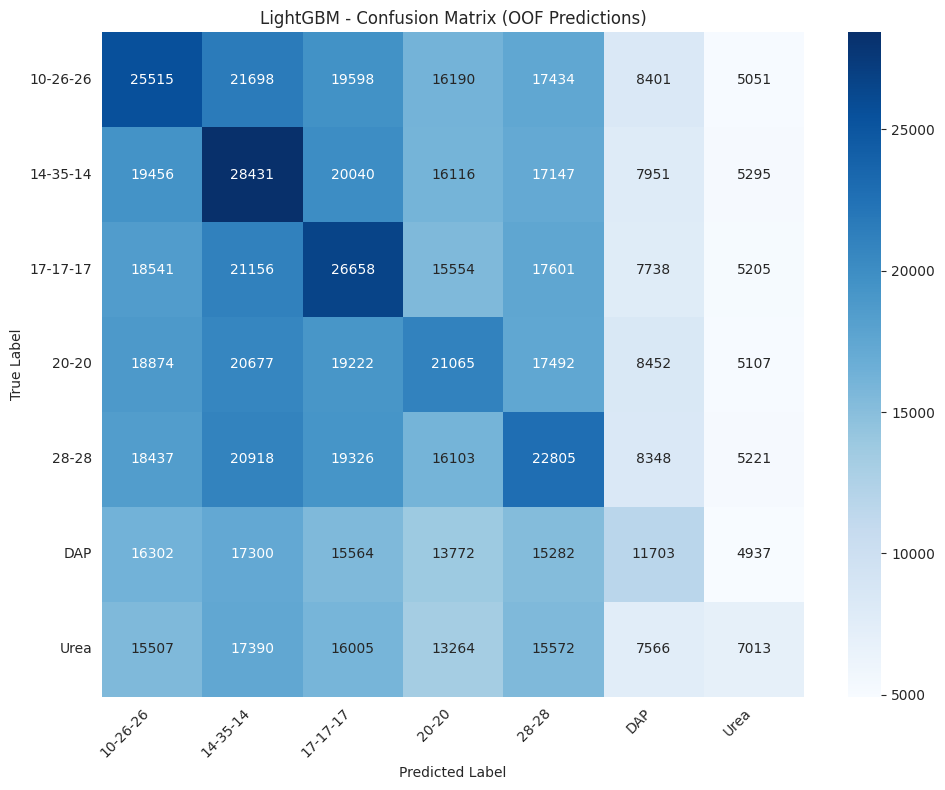


Training CatBoost...
--- CatBoost - Fold 1/5 ---
Fold 1 MAP@3: 0.3195
--- CatBoost - Fold 2/5 ---
Fold 2 MAP@3: 0.3208
--- CatBoost - Fold 3/5 ---
Fold 3 MAP@3: 0.3197
--- CatBoost - Fold 4/5 ---
Fold 4 MAP@3: 0.3198
--- CatBoost - Fold 5/5 ---
Fold 5 MAP@3: 0.3199
CatBoost - Mean OOF MAP@3: 0.3199
Confusion matrix for CatBoost saved to model_diagnostics_kfold/catboost_oof_confusion_matrix.png


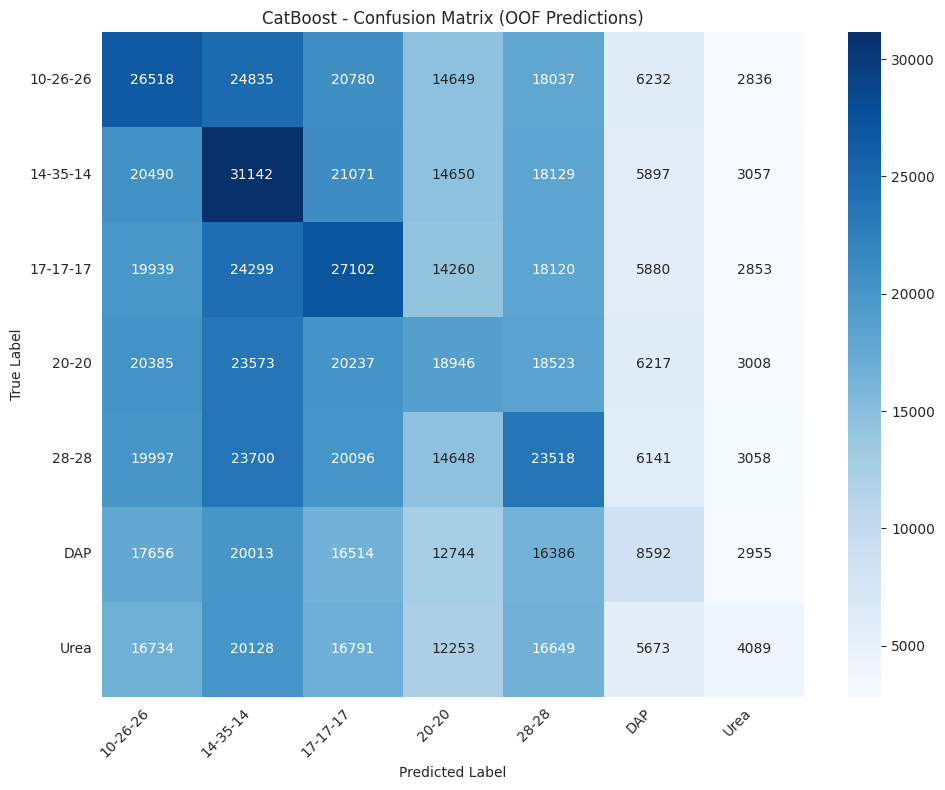


Training XGBoost...
--- XGBoost - Fold 1/5 ---
Fold 1 MAP@3: 0.3299
--- XGBoost - Fold 2/5 ---
Fold 2 MAP@3: 0.3313
--- XGBoost - Fold 3/5 ---
Fold 3 MAP@3: 0.3311
--- XGBoost - Fold 4/5 ---
Fold 4 MAP@3: 0.3314
--- XGBoost - Fold 5/5 ---
Fold 5 MAP@3: 0.3309
XGBoost - Mean OOF MAP@3: 0.3309
Confusion matrix for XGBoost saved to model_diagnostics_kfold/xgboost_oof_confusion_matrix.png


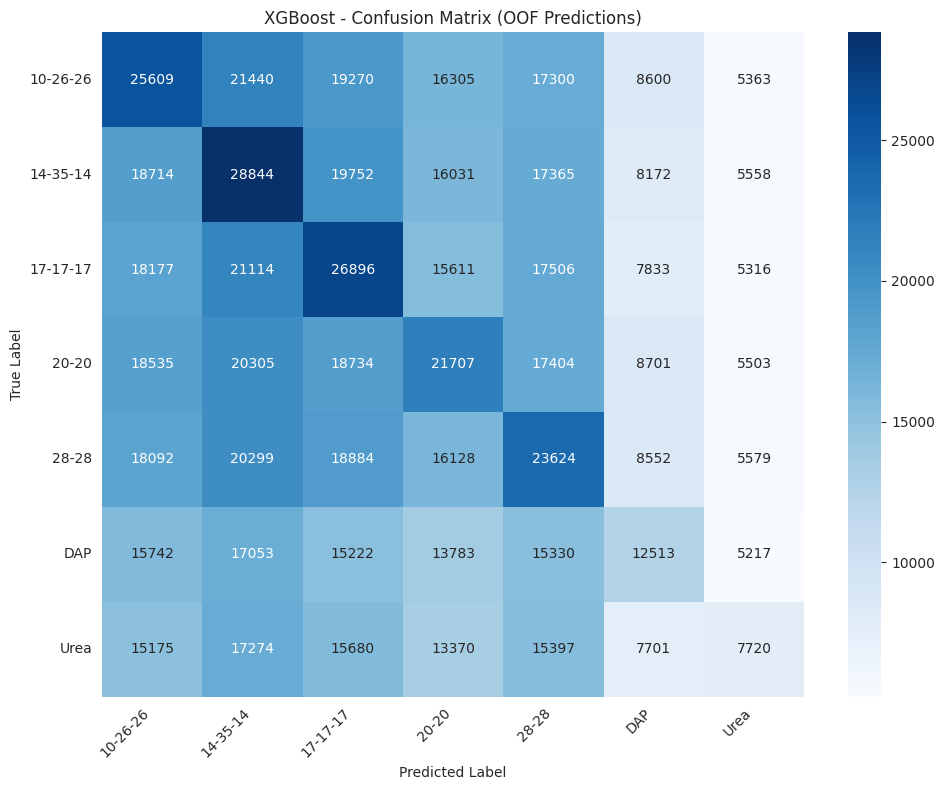


--- Base Model OOF MAP@3 Scores ---
lgbm: 0.3255
catboost: 0.3199
xgboost: 0.3309


In [10]:
target_class_names = target_encoder.classes_
all_oof_preds = {}
all_test_preds = {}
all_mean_map3_scores = {}
all_trained_models = {}

# LightGBM
print("\nTraining LightGBM...")
lgbm_models, lgbm_oof, lgbm_test, lgbm_map3 = train_model_kfold(
    lgb.LGBMClassifier, lgbm_params, X_train_final, y_series, X_test_final, N_FOLDS, 'LightGBM', target_class_names
)
all_oof_preds['lgbm'] = lgbm_oof
all_test_preds['lgbm'] = lgbm_test
all_mean_map3_scores['lgbm'] = lgbm_map3
all_trained_models['lgbm'] = lgbm_models
joblib.dump(lgbm_models, os.path.join(MODEL_DIR, 'lgbm_kfold_models.joblib'))

# CatBoost
print("\nTraining CatBoost...")
cat_models, cat_oof, cat_test, cat_map3 = train_model_kfold(
    CatBoostClassifier, catboost_params, X_train_final, y_series, X_test_final, N_FOLDS, 'CatBoost', target_class_names
)
all_oof_preds['catboost'] = cat_oof
all_test_preds['catboost'] = cat_test
all_mean_map3_scores['catboost'] = cat_map3
all_trained_models['catboost'] = cat_models
joblib.dump(cat_models, os.path.join(MODEL_DIR, 'catboost_kfold_models.joblib'))

# XGBoost
print("\nTraining XGBoost...")
xgb_models, xgb_oof, xgb_test, xgb_map3 = train_model_kfold(
    xgb.XGBClassifier, xgb_params, X_train_final, y_series, X_test_final, N_FOLDS, 'XGBoost', target_class_names
)
all_oof_preds['xgboost'] = xgb_oof
all_test_preds['xgboost'] = xgb_test
all_mean_map3_scores['xgboost'] = xgb_map3
all_trained_models['xgboost'] = xgb_models
joblib.dump(xgb_models, os.path.join(MODEL_DIR, 'xgboost_kfold_models.joblib'))

print("\n--- Base Model OOF MAP@3 Scores ---")
for model_name, score in all_mean_map3_scores.items():
    print(f"{model_name}: {score:.4f}")

## 5. Stacking with Logistic Regression
Using the OOF predictions from base models as features for a meta-model.


5. Stacking with Logistic Regression...
Stacked OOF features shape: (750000, 21)
Stacked Test features shape: (250000, 21)
Meta-Model (Logistic Regression) OOF MAP@3: 0.3312
Confusion matrix for MetaModel_LogisticRegression saved to model_diagnostics_kfold/metamodel_logisticregression_oof_confusion_matrix.png


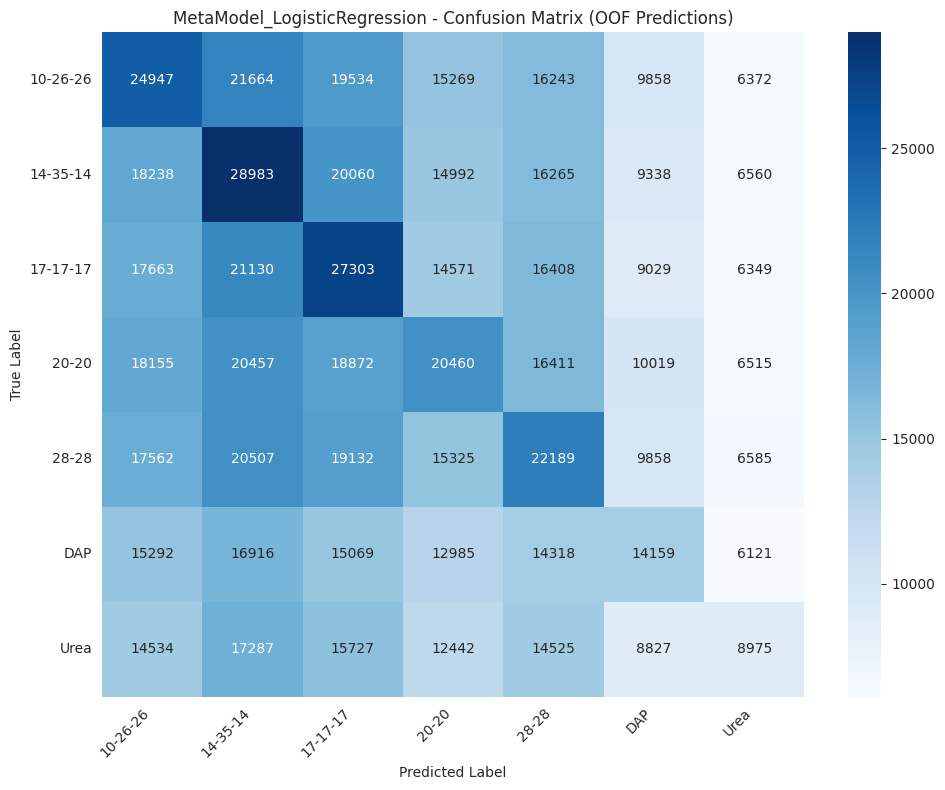

array([[24947, 21664, 19534, 15269, 16243,  9858,  6372],
       [18238, 28983, 20060, 14992, 16265,  9338,  6560],
       [17663, 21130, 27303, 14571, 16408,  9029,  6349],
       [18155, 20457, 18872, 20460, 16411, 10019,  6515],
       [17562, 20507, 19132, 15325, 22189,  9858,  6585],
       [15292, 16916, 15069, 12985, 14318, 14159,  6121],
       [14534, 17287, 15727, 12442, 14525,  8827,  8975]])

In [11]:
print("\n5. Stacking with Logistic Regression...")
X_oof_stacked = np.concatenate([
    all_oof_preds['lgbm'], 
    all_oof_preds['catboost'], 
    all_oof_preds['xgboost']
], axis=1)

X_test_stacked = np.concatenate([
    all_test_preds['lgbm'], 
    all_test_preds['catboost'], 
    all_test_preds['xgboost']
], axis=1)

print(f"Stacked OOF features shape: {X_oof_stacked.shape}")
print(f"Stacked Test features shape: {X_test_stacked.shape}")

meta_model = LogisticRegression(**lr_params)
scaler = StandardScaler() # Scale stacked features
X_oof_stacked_scaled = scaler.fit_transform(X_oof_stacked)
X_test_stacked_scaled = scaler.transform(X_test_stacked)

meta_model.fit(X_oof_stacked_scaled, y_series)
joblib.dump(meta_model, os.path.join(MODEL_DIR, 'meta_model_logistic_regression.joblib'))
joblib.dump(scaler, os.path.join(MODEL_DIR, 'stacking_scaler.joblib'))

# Evaluate meta-model on OOF predictions (as an estimate of performance)
meta_oof_pred_proba = meta_model.predict_proba(X_oof_stacked_scaled)
meta_map3_score = map_at_k(y_series.values, meta_oof_pred_proba, k=3)
print(f"Meta-Model (Logistic Regression) OOF MAP@3: {meta_map3_score:.4f}")

# Plot confusion matrix for the meta-model based on its OOF predictions
meta_oof_pred_classes = np.argmax(meta_oof_pred_proba, axis=1)
plot_and_save_confusion_matrix(y_series, meta_oof_pred_classes, target_class_names, "MetaModel_LogisticRegression", save_dir=DIAGNOSTICS_DIR)

## 6. Prediction and Submission
Generate final predictions on the test set using the trained meta-model.

In [12]:
print("\n6. Generating final test predictions with meta-model...")
final_test_pred_proba = meta_model.predict_proba(X_test_stacked_scaled)

# Get top 3 predictions
top_3_indices = np.argsort(final_test_pred_proba, axis=1)[:, -3:][:, ::-1]
top_3_labels = target_encoder.inverse_transform(top_3_indices.ravel()).reshape(top_3_indices.shape)

submission_fertilizer_names = [' '.join(label_row) for label_row in top_3_labels]

submission_df = pd.DataFrame({
    'id': test_ids,
    'Fertilizer Name': submission_fertilizer_names
})

submission_file_path = 'submission_stacked_ensemble.csv'
submission_df.to_csv(submission_file_path, index=False)
print(f"Submission file created at: {submission_file_path}")
display(submission_df.head())


6. Generating final test predictions with meta-model...
Submission file created at: submission_stacked_ensemble.csv


,id,Fertilizer Name
0,750000,DAP 28-28 14-35-14
1,750001,17-17-17 20-20 10-26-26
2,750002,10-26-26 20-20 14-35-14
3,750003,14-35-14 17-17-17 10-26-26
4,750004,20-20 10-26-26 17-17-17


## 7. Saving Artifacts
Saving encoders and feature names for the `Predictor` notebook.

In [13]:
print("\n7. Saving other artifacts...")
joblib.dump(column_encoder, os.path.join(MODEL_DIR, 'dataframe_column_encoder.joblib'))
joblib.dump(target_encoder, os.path.join(MODEL_DIR, 'target_label_encoder.joblib'))
joblib.dump(X_train_final.columns.tolist(), os.path.join(MODEL_DIR, 'feature_names.joblib'))

print("All models and artifacts saved.")
print(f"Models saved in: {MODEL_DIR}")
print(f"Diagnostics (CMs) saved in: {DIAGNOSTICS_DIR}")


7. Saving other artifacts...
All models and artifacts saved.
Models saved in: trained_models_kfold
Diagnostics (CMs) saved in: model_diagnostics_kfold


## 8. Training Summary Plot (Optional)
Plotting MAP@3 scores for base models and the ensemble.

Model performance summary plot saved to model_diagnostics_kfold/model_performance_summary.png


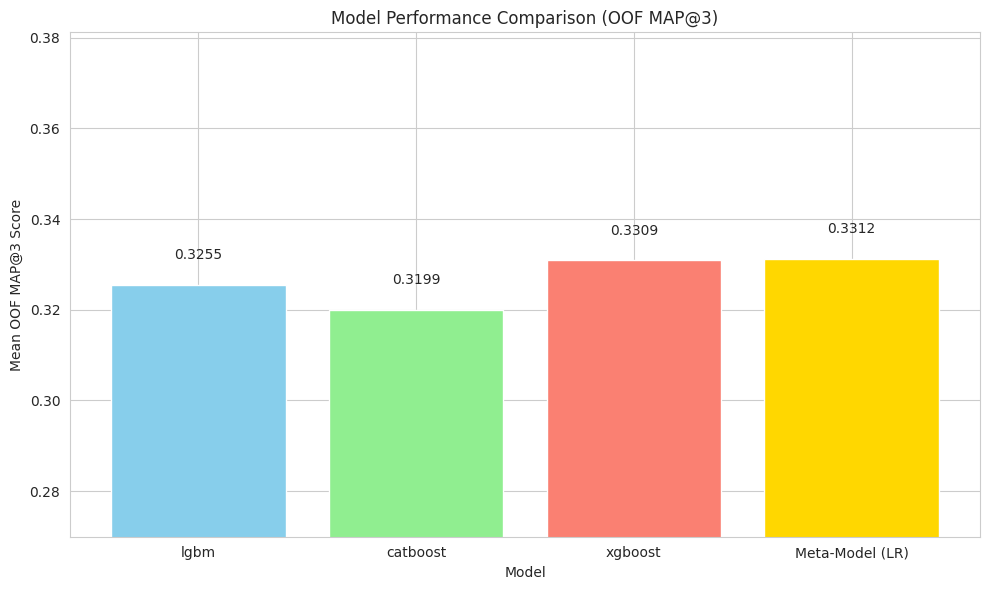

In [14]:
model_names_plot = list(all_mean_map3_scores.keys()) + ['Meta-Model (LR)']
map3_scores_plot = list(all_mean_map3_scores.values()) + [meta_map3_score]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names_plot, map3_scores_plot, color=['skyblue', 'lightgreen', 'salmon', 'gold'])
plt.xlabel('Model')
plt.ylabel('Mean OOF MAP@3 Score')
plt.title('Model Performance Comparison (OOF MAP@3)')
plt.ylim(min(map3_scores_plot) - 0.05, max(map3_scores_plot) + 0.05)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom')

plt.tight_layout()
summary_plot_path = os.path.join(DIAGNOSTICS_DIR, 'model_performance_summary.png')
plt.savefig(summary_plot_path)
print(f"Model performance summary plot saved to {summary_plot_path}")
plt.show()